<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_22_5_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


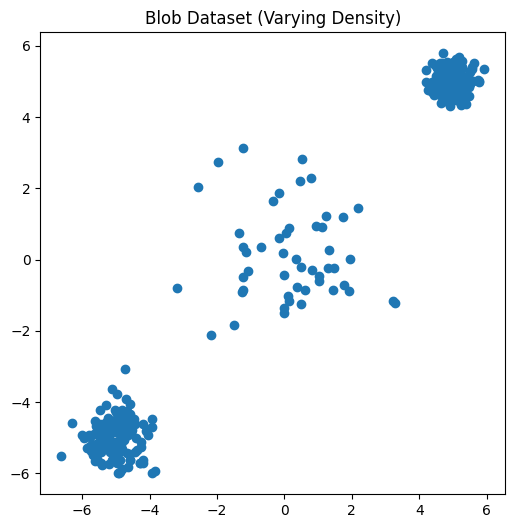

In [18]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd

# Ensure data is generated if kernel was restarted
print(X_blobs.shape)

# TODO: Scale the dataset and verify that the mean is ~0 and variance is ~1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_blobs)

X_scaled_mean = X_scaled.mean()
X_scaled_std = X_scaled.std()
X_scaled_var = X_scaled.var()
print('Mean:', round(X_scaled_mean, 2))
print('Std', round(X_scaled_std, 2))
print('Variance', round(X_scaled_var, 2))

# Challenge: Check the summary statistics of the scaled data
df_scaled = pd.DataFrame(X_scaled, columns = ['feature_1', 'feature_2'])
print(df_scaled.describe())

# Why is scaling important here?
# Ans: Scaling makes both features have the same range (mean 0, std 1). Without it, a feature with bigger numbers would unfairly dominate calculations like distance, even if it's not more important.

# What happens if we skip scaling?
# Ans: Algorithms like KMeans use distance between points. If one feature has much bigger values than the other,
# it will control the distance calculation and mess up the clustering — even if that feature isn't actually more useful.

(400, 2)
Mean: 0.0
Std 1.0
Variance 1.0
          feature_1     feature_2
count  4.000000e+02  4.000000e+02
mean   5.773160e-17 -6.439294e-17
std    1.001252e+00  1.001252e+00
min   -1.552926e+00 -1.423594e+00
25%   -1.172044e+00 -1.159617e+00
50%    6.645817e-01  6.608559e-01
75%    9.330801e-01  9.311268e-01
max    1.132521e+00  1.103948e+00



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


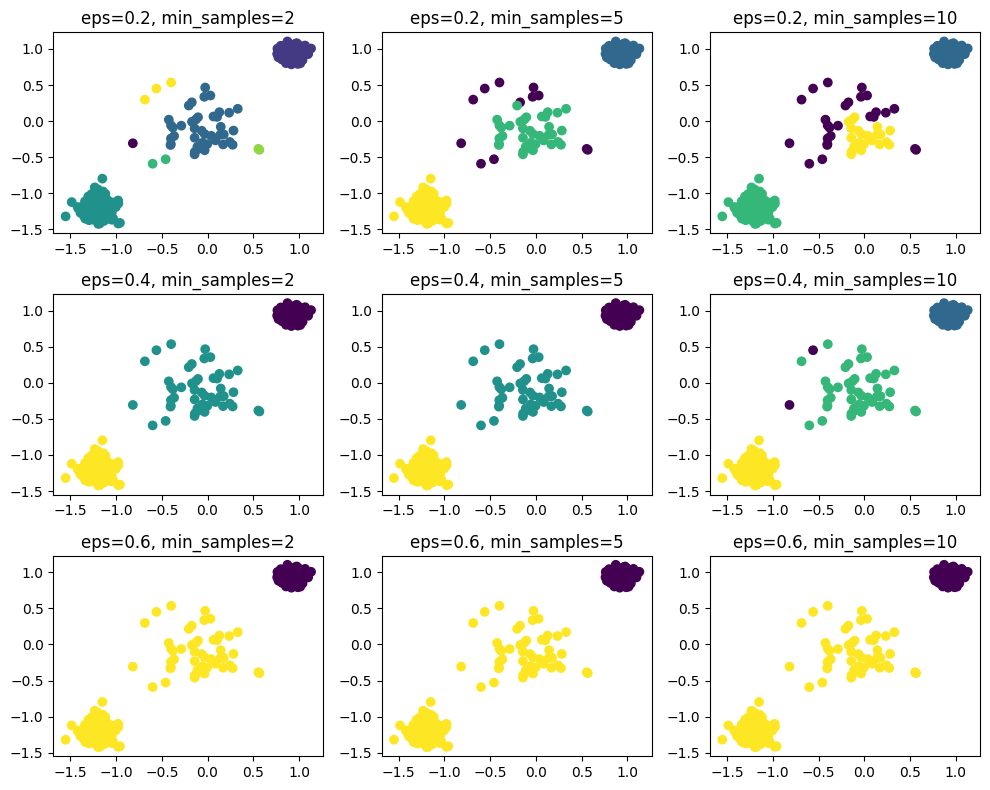

In [23]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.

eps = [0.2, 0.4, 0.6]
min_samples = [2, 5, 10]

fig, axes = plt.subplots(3, 3, figsize = (10, 8))

for i, eps in enumerate(eps):
  for j, samp in enumerate(min_samples):
    dbscan = DBSCAN(eps = eps, min_samples = samp)
    labels = dbscan.fit_predict(X_scaled)

    ax = axes[i][j]
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c = labels, cmap = 'viridis')
    ax.set_title(f'eps={eps}, min_samples={samp}')

plt.tight_layout()
plt.show()


### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


Estimated eps: 0.17


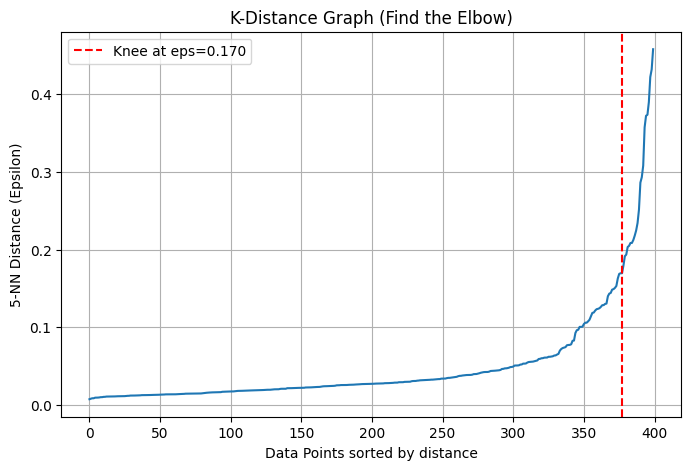

In [40]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
from kneed import KneeLocator

# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.
neighbors = NearestNeighbors(n_neighbors = 5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort
distances = np.sort(distances[:, 4], axis = 0)

# Use the 'knee' point detection logic.
kneedle = KneeLocator(range(len(distances)), distances, curve = 'convex', direction = 'increasing')
knee_point = kneedle.knee
eps_estimate = distances[knee_point]
print("Estimated eps:", round(eps_estimate, 3))

# plot
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.axvline(x=knee_point, color='r', linestyle='--', label=f'Knee at eps={eps_estimate:.3f}')
plt.title("K-Distance Graph (Find the Elbow)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("5-NN Distance (Epsilon)")
plt.legend()
plt.grid(True)
plt.show()


## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


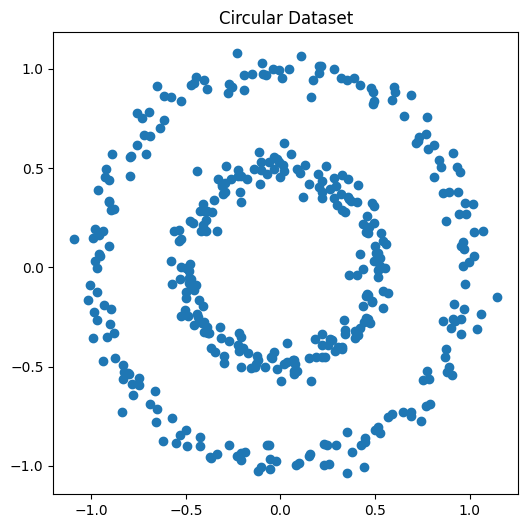

In [46]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


(400, 2)


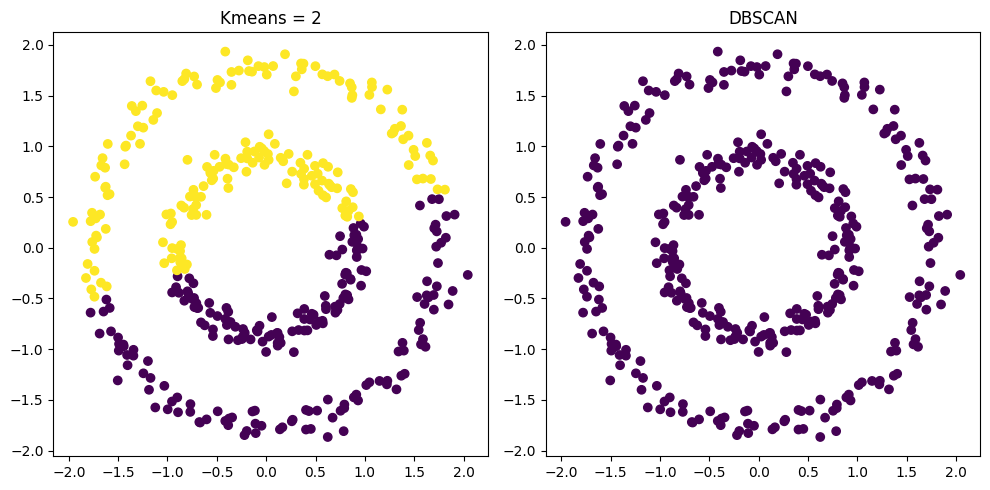

In [54]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure data is generated
print(X_circles.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)
dbscan = DBSCAN(eps = 0.5, min_samples = 5)
dbscan.fit(X_scaled)
label_dbscan = dbscan.labels_

kmeans = KMeans(n_clusters=2, init = 'k-means++', max_iter = 400, random_state = 42)
kmeans.fit(X_scaled)
label_kmeans = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c = label_kmeans, cmap = 'viridis')
axes[0].set_title('Kmeans = 2')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c = label_dbscan, cmap = 'viridis')
axes[1].set_title('DBSCAN')


plt.tight_layout()
plt.show()

# KMeans (Expect failure for non-convex shapes)
# Ans: The kmeans has divided the 2 clusters based on the distances which is not expected. the clusters should be circular. So it was a failure

# DBSCAN (Expect success for dense regions)
# Ans: DBSCAN successfully divided clusters in the expected manner based on the densed area.


## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


In [58]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

linkage = ['single', 'complete', 'average', 'ward']

for link in linkage:
  model = AgglomerativeClustering(n_clusters = 2, linkage = link)
  labels = model.fit_predict(X_scaled)

  score = silhouette_score(X_scaled, labels)
  print(f'Linkage: {link} -> Silhoutte Scores: {round(score, 2)}')

Linkage: single -> Silhoutte Scores: 0.11
Linkage: complete -> Silhoutte Scores: 0.35
Linkage: average -> Silhoutte Scores: 0.35
Linkage: ward -> Silhoutte Scores: 0.33



### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


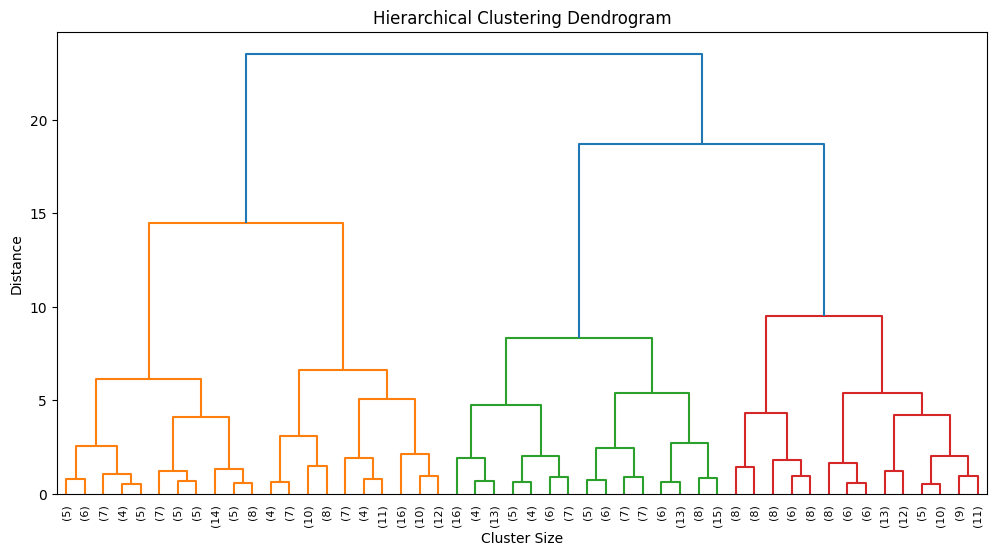

In [63]:
from scipy.cluster.hierarchy import dendrogram, linkage

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

# TODO: Create dendrogram here
link = linkage(X_scaled, method = 'ward')

plt.figure(figsize=(12, 6))
dendrogram(link, truncate_mode = 'lastp', p = 50)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.

(1000, 3)
Best eps, min_samples: (np.float64(0.1), np.int64(10))
Best silhouette score: 0.93


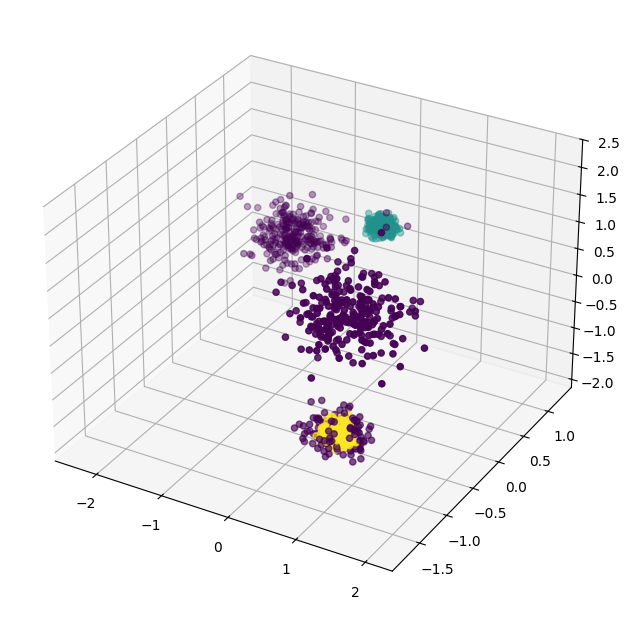

In [70]:
from mpl_toolkits.mplot3d import Axes3D

# Generate 3D Data: Use make_blobs to create 1000 samples in 3D space with varying standard deviations.
X_3d, y_3d = make_blobs(
    n_samples=1000,
    n_features=3,
    centers=4,
    cluster_std=[0.5, 1.0, 1.5, 2.0],  # varying std devs
    random_state=42
)

scaler = StandardScaler()
X_3d_scaled = scaler.fit_transform(X_3d)
print(X_3d_scaled.shape)

# Parameter Grid Search: Write a loop that tests eps from 0.1 to 1.0 and min_samples from 2 to 10.
best_score = -1
best_params = None
best_labels = None

eps = np.arange(0.1, 1.01, 0.1)
min_sample = np.arange(2, 11, 1)

for i, eps in enumerate(eps):
  for j, samp in enumerate(min_sample):
    dbscan = DBSCAN(eps = eps, min_samples=samp)
    labels = dbscan.fit_predict(X_3d_scaled)

    mask = labels != -1
    if(len(set(labels[mask])) < 2):
      continue

    # Optimization: Find the combination that maximizes the silhouette_score (excluding noise points).
    sil_score = silhouette_score(X_3d_scaled[mask], labels[mask])

    if sil_score > best_score:
      best_score = sil_score
      best_params = (eps, samp)
      best_labels = labels

print("Best eps, min_samples:", best_params)
print("Best silhouette score:", round(best_score, 2))

# 3D Visualization: Plot the final optimized clusters using a 3D scatter plot.
fig = plt.figure(figsize = (10, 6))

ax = Axes3D(fig)
fig.add_axes(ax)
ax.scatter(X_3d_scaled[:, 0], X_3d_scaled[:, 1], X_3d_scaled[:, 2], c = best_labels, cmap = 'viridis')
plt.show()